# Chapter 2 — Advanced Exercises

> **📗 Solutions version.** Reference answers and worked code are included below each problem. A companion **(Student)** notebook has the same problems with the answers blanked out.
## Solving the Inference Bottleneck: KV Cache, MQA & GQA

**Course level:** Advanced graduate (Georgia Tech CS 8803 / Stanford CS 224N–CS 336 style).
Companion problem set for Chapter 2 of *Build a DeepSeek Model (From Scratch)*.

These exercises reinforce the chapter through a mix of **theory** (derivations, complexity, proofs)
and **practice** (from-scratch PyTorch, numerical-equivalence tests, micro-benchmarks).

### Learning objectives
By the end you will be able to:
1. Derive the time/space complexity of cached vs. uncached autoregressive decoding from first principles.
2. Implement a **numerically exact** incremental KV cache and prove it equals full recomputation.
3. Derive and reproduce the KV-cache memory formula for real models (GPT-2 → DeepSeek-V3).
4. Implement **MQA** and **GQA** from scratch with a tunable group knob and prove the MHA↔MQA spectrum.
5. Quantify the **expressivity vs. memory** trade-off empirically on a controlled task.

### How to use this notebook
Each exercise has: a **problem statement** (theory ✏️ + code 💻), a **student stub** with `# TODO`,
a clearly marked **reference solution** cell (try it yourself first!), and an **autograder** cell
with `assert`-based checks. Running top-to-bottom executes as an answer key; comment out the
solution cells to work the problems yourself.


In [1]:
# --- Setup ---
import math, time, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

def check(name, got, want, atol=1e-5):
    ok = abs(float(got) - float(want)) <= atol
    print(("PASS " if ok else "FAIL ") + f"{name}: got={got:.3e} want={want:.3e}")
    assert ok, f"{name} failed"

def close(name, a, b, atol=1e-5):
    d = (a - b).abs().max().item()
    ok = d <= atol
    print(("PASS " if ok else "FAIL ") + f"{name}: max|Δ|={d:.3e} (atol={atol})")
    assert ok, f"{name} failed (max|Δ|={d})"


torch 2.9.0+cu130 | device: cuda


---
## Exercise 1 — Complexity of cached vs. uncached decoding ✏️💻
**Difficulty: ★★☆**

The chapter argues uncached generation is $O(n^2)$ and caching makes it $O(n)$. Make this precise.

Consider a single attention layer, model dim $d$, $H$ heads, head dim $d_h=d/H$, generating
tokens one at a time up to a final length $n$ (ignore the FFN and the vocab projection for now).

**Part A (theory).** Let the *prefill+decode* cost be the total work to generate all $n$ tokens.
1. For the **uncached** loop, at step $t$ the model re-runs the full prefix of length $t$. Write the
   per-step cost of (i) the QKV projections and (ii) the $QK^\top$ + $AV$ attention, then sum over
   $t=1..n$. Show the dominant term in $n$ for each.
2. For the **cached** loop, at step $t$ we project only the *new* token and attend it against $t$
   cached keys. Give the per-step and total cost.
3. Conclude the asymptotic totals. Which one is quadratic in $n$ *for the projections*, and which
   part is quadratic in *both* cases?

> Write your answer in the markdown cell below, then implement the FLOP model in code and confirm
> the empirical slopes match your derivation.


**Your answer (Part A).**

*(Double-click to edit.)*

<details><summary>Reference answer</summary>

Let projection cost per token $\approx 4 d^2$ (the $W_q,W_k,W_v,W_o$ matmuls, each $\sim d^2$ MACs)
and attention cost for a query against $L$ keys $\approx 2\,d\,L$ (the $QK^\top$ and $AV$ contractions, summed over heads give $\sim d\,L$ each).

**Uncached** — at step $t$ we reprocess the whole prefix of length $t$:
- projections: $\sum_{t=1}^n 4 d^2 t = 4 d^2 \frac{n(n+1)}{2} = O(d^2 n^2)$ ← *quadratic, and this dominates because of the $d^2$ factor*
- attention: $\sum_{t=1}^n 2 d\, t^2 = O(d\, n^3)$ if you recompute all rows; if you (wastefully) only keep the last row's scores it is $\sum 2 d t = O(d n^2)$.

**Cached** — at step $t$ we project 1 new token and attend it to $t$ keys:
- projections: $\sum_{t=1}^n 4 d^2 = O(d^2 n)$ ← *linear*
- attention: $\sum_{t=1}^n 2 d\, t = O(d\, n^2)$ ← *still quadratic*, because the cumulative score computation over a growing context is irreducible.

**Conclusion.** Caching removes the quadratic blow-up of the **projections** (the expensive $d^2$ term),
turning total work from $O(d^2 n^2)$ to $O(d^2 n + d n^2)$. For realistic $d \gg n$ the projection term dominates,
so the practical speedup tracks the $n^2 \to n$ improvement the chapter measures (~5×).
</details>


In [2]:
# 1B (code): theoretical FLOP model. Fill in the per-step costs, then we plot totals vs n.
def flops_uncached(n, d):
    # TODO: return total MAC count to generate n tokens WITHOUT a KV cache
    # projections cost ~4*d*d per processed token; reprocess prefix of length t at step t.
    # attention cost ~2*d*L for a length-L context (sum the last-row score+context work).
    raise NotImplementedError

def flops_cached(n, d):
    # TODO: with a KV cache, project only the new token each step; attend it to t keys.
    raise NotImplementedError


**Reference solution (Ex.1B)** — try the stub first.

empirical slope (uncached) ~ 1.99  (expect ~2)
empirical slope (cached)   ~ 1.14  (expect ~1, drifts up as d n^2 term grows)


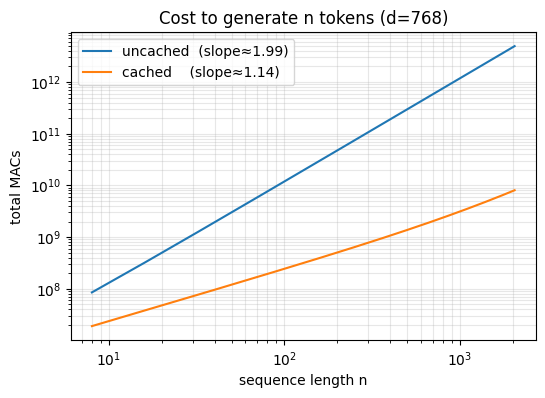

OK


In [3]:
def flops_uncached(n, d):
    proj = sum(4*d*d*t for t in range(1, n+1))      # reprocess full prefix
    attn = sum(2*d*t for t in range(1, n+1))        # last-row scores+context over growing ctx
    return proj + attn

def flops_cached(n, d):
    proj = sum(4*d*d for _ in range(1, n+1))        # only the new token
    attn = sum(2*d*t for t in range(1, n+1))        # one query vs t keys
    return proj + attn

import numpy as np
ns = np.arange(8, 2049, 8); d = 768
fu = np.array([flops_uncached(int(n), d) for n in ns])
fc = np.array([flops_cached(int(n), d) for n in ns])

# empirical log-log slope of the projection-dominated regime
su = np.polyfit(np.log(ns), np.log(fu), 1)[0]
sc = np.polyfit(np.log(ns), np.log(fc), 1)[0]
print(f"empirical slope (uncached) ~ {su:.2f}  (expect ~2)")
print(f"empirical slope (cached)   ~ {sc:.2f}  (expect ~1, drifts up as d n^2 term grows)")

plt.figure(figsize=(6,4))
plt.loglog(ns, fu, label=f"uncached  (slope≈{su:.2f})")
plt.loglog(ns, fc, label=f"cached    (slope≈{sc:.2f})")
plt.xlabel("sequence length n"); plt.ylabel("total MACs"); plt.legend()
plt.title("Cost to generate n tokens (d=768)"); plt.grid(True, which="both", alpha=.3); plt.show()
assert 1.8 < su < 2.05, "uncached should be ~quadratic"
print("OK")


---
## Exercise 2 — Exact incremental KV cache 💻
**Difficulty: ★★★** *(the heart of the chapter)*

Implement causal **Multi-Head Attention** that supports an **incremental KV cache**: a
`forward(x, past)` that, given the embedding of *new* tokens and the cached `(K, V)` for the prefix,
returns the output and the *updated* cache.

**Requirements**
1. Correct **causal masking** even when the query block is shorter than the key block (the new
   tokens may only attend to themselves and the past, not to each other's future).
2. **Numerical equivalence**: decoding token-by-token with the cache must equal a single full-sequence
   forward pass to within float tolerance.

**Part A (theory).** Explain *why* only $K$ and $V$ are cached and not $Q$. Tie your answer to the
chapter's "only the last row matters" insight.


**Your answer (2A).**

<details><summary>Reference</summary>
The next-token logit depends only on the **last** query row's context vector. The query for a *past*
token is never needed again — at every step we form a fresh query for the current token only. But
that current query must attend to **all** past keys/values, which do not change once computed
(fixed weights, fixed past embeddings). So $K,V$ are reusable history (cache them) while $Q$ is
always recomputed for the single current position (no benefit to caching).
</details>


In [4]:
# 2 (code): complete the cached MHA.
class CausalMHA(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh, self.d = num_heads, d_model // num_heads, d_model
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def _split(self, x, B, T):
        return x.view(B, T, self.h, self.dh).transpose(1, 2)   # (B,h,T,dh)

    def forward(self, x, past=None):
        # x: (B, T_new, d).  past: tuple (K,V) each (B,h,T_past,dh) or None.
        # TODO: project q,k,v for the NEW tokens; concat k,v onto past; build a causal mask
        # that accounts for the query offset (T_k - T_new); softmax; output; return (out, (K,V)).
        raise NotImplementedError


**Reference solution (Ex.2)**

In [5]:
class CausalMHA(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh, self.d = num_heads, d_model // num_heads, d_model
        self.W_q = nn.Linear(d_model, d_model); self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model); self.W_o = nn.Linear(d_model, d_model)
    def _split(self, x, B, T):
        return x.view(B, T, self.h, self.dh).transpose(1, 2)
    def forward(self, x, past=None):
        B, T, _ = x.shape
        q = self._split(self.W_q(x), B, T)
        k = self._split(self.W_k(x), B, T)
        v = self._split(self.W_v(x), B, T)
        if past is not None:
            pk, pv = past
            k = torch.cat([pk, k], dim=2); v = torch.cat([pv, v], dim=2)
        Tk = k.shape[2]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
        # query positions are the LAST T of the Tk-long context
        qpos = torch.arange(Tk - T, Tk, device=x.device).view(T, 1)
        kpos = torch.arange(Tk, device=x.device).view(1, Tk)
        scores = scores.masked_fill(kpos > qpos, float("-inf"))
        w = F.softmax(scores, dim=-1)
        ctx = (w @ v).transpose(1, 2).contiguous().view(B, T, self.d)
        return self.W_o(ctx), (k, v)


In [6]:
# 2 (autograder): incremental decode == full forward
m = CausalMHA(64, 8).eval()
x = torch.randn(2, 12, 64)
with torch.no_grad():
    full, _ = m(x)                       # one shot
    past, outs = None, []
    for t in range(x.shape[1]):          # token-by-token
        o, past = m(x[:, t:t+1], past)
        outs.append(o)
    inc = torch.cat(outs, dim=1)
close("KV-cache incremental == full", full, inc, atol=1e-4)
# bonus: prefill a chunk, then decode the rest -> must also match
with torch.no_grad():
    o0, past = m(x[:, :5])
    rest = [o0]
    for t in range(5, x.shape[1]):
        o, past = m(x[:, t:t+1], past); rest.append(o)
    chunked = torch.cat(rest, dim=1)
close("chunked prefill+decode == full", full, chunked, atol=1e-4)


PASS KV-cache incremental == full: max|Δ|=3.576e-07 (atol=0.0001)
PASS chunked prefill+decode == full: max|Δ|=1.788e-07 (atol=0.0001)


---
## Exercise 3 — The KV-cache memory formula ✏️💻
**Difficulty: ★★☆**

The chapter's formula is
$$\text{bytes} = \underbrace{2}_{K,V}\cdot \underbrace{2}_{\text{bytes/elt (fp16)}}\cdot l \cdot b \cdot n \cdot h \cdot s$$
where $l$=layers, $b$=batch, $n$=heads, $h$=head dim, $s$=sequence length.

**Part A (code).** Implement `kv_bytes(...)` and reproduce the chapter's landmark numbers:
- GPT-2 small style (~36 MB regime), GPT-3 175B (~4.5 GB), and a DeepSeek-V3-scale point
  ($l=61$, $n\!\cdot\!h=16384$, $s=100{,}000$, $b=1$) ≈ **~400 GB**.

**Part B (theory).** The text says inference becomes *memory-bandwidth bound*. For the DeepSeek-V3-scale
cache, estimate the bytes that must be streamed from HBM **per generated token** (you read the whole
cache once per token). If an H100 delivers ~3.35 TB/s of HBM bandwidth, what is the bandwidth-limited
*lower bound* on per-token latency? Comment on why this motivates MLA.


In [7]:
# 3A (code): fill in the formula
def kv_bytes(layers, batch, n_heads, head_dim, seq_len, bytes_per_elt=2):
    # TODO: return total KV-cache size in bytes (count BOTH K and V).
    raise NotImplementedError


**Reference solution (Ex.3A)**

In [8]:
def kv_bytes(layers, batch, n_heads, head_dim, seq_len, bytes_per_elt=2):
    return 2 * bytes_per_elt * layers * batch * n_heads * head_dim * seq_len

GB = 1024**3; MB = 1024**2
v3 = kv_bytes(layers=61, batch=1, n_heads=128, head_dim=128, seq_len=100_000)
print(f"DeepSeek-V3-scale single-seq cache ≈ {v3/GB:6.1f} GB")
big30 = kv_bytes(layers=48, batch=128, n_heads=1, head_dim=7168, seq_len=1024)
print(f"30B-style (n*h=7168), batch=128, s=1024 ≈ {big30/GB:6.1f} GB")
assert 350 < v3/GB < 450, "should be ~400 GB"

# 3B: bandwidth-limited per-token latency
HBM_BW = 3.35e12  # bytes/s (H100-class)
print(f"per-token HBM read ≈ {v3/GB:.0f} GB ; lower-bound latency ≈ {v3/HBM_BW*1e3:.1f} ms/token")
print("=> reading a ~400GB cache once per token alone caps you near ~0.1s/token — MLA shrinks this cache ~60x.")


DeepSeek-V3-scale single-seq cache ≈  372.3 GB
30B-style (n*h=7168), batch=128, s=1024 ≈  168.0 GB
per-token HBM read ≈ 372 GB ; lower-bound latency ≈ 119.3 ms/token
=> reading a ~400GB cache once per token alone caps you near ~0.1s/token — MLA shrinks this cache ~60x.


---
## Exercise 4 — MQA and GQA from scratch + the tunable knob 💻✏️
**Difficulty: ★★★**

Implement a single `GroupedQueryAttention(d_model, num_heads, num_groups)` that:
- projects $K,V$ to `num_groups * d_head` and broadcasts groups to heads with `repeat_interleave`;
- reduces to **MQA** when `num_groups == 1` and to **MHA** when `num_groups == num_heads`.

**Part A (code).** Implement it (causal). **Part B (proof).** Show that broadcasting a group's K to its
member heads via `repeat_interleave` is *mathematically identical* to giving those heads tied
$W_k$ weight matrices (i.e., GQA = weight-tying, not a post-hoc hack). Verify numerically.
**Part C (code).** Verify the spectrum: with identical inputs, `num_groups=H` reproduces a reference MHA
and the per-token **KV-cache width** scales as `num_groups`.


In [9]:
# 4A (code): complete GQA
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_groups):
        super().__init__()
        assert d_model % num_heads == 0 and num_heads % num_groups == 0
        self.h, self.g, self.dh, self.d = num_heads, num_groups, d_model//num_heads, d_model
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, num_groups * (d_model//num_heads))
        self.W_v = nn.Linear(d_model, num_groups * (d_model//num_heads))
        self.W_o = nn.Linear(d_model, d_model)
    def forward(self, x):
        B, T, _ = x.shape
        # TODO: q -> (B,h,T,dh); k,v -> (B,g,T,dh) then repeat_interleave to (B,h,T,dh);
        # causal scores; softmax; output.  Return (B,T,d).
        raise NotImplementedError
    def kv_cache_width(self):
        # TODO: per-token number of cached K/V scalars (both K and V)
        raise NotImplementedError


**Reference solution (Ex.4)**

In [10]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_groups):
        super().__init__()
        assert d_model % num_heads == 0 and num_heads % num_groups == 0
        self.h, self.g, self.dh, self.d = num_heads, num_groups, d_model//num_heads, d_model
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, num_groups * self.dh)
        self.W_v = nn.Linear(d_model, num_groups * self.dh)
        self.W_o = nn.Linear(d_model, d_model)
    def forward(self, x):
        B, T, _ = x.shape
        q = self.W_q(x).view(B, T, self.h, self.dh).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.g, self.dh).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.g, self.dh).transpose(1, 2)
        k = k.repeat_interleave(self.h // self.g, dim=1)
        v = v.repeat_interleave(self.h // self.g, dim=1)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), 1)
        scores = scores.masked_fill(mask, float("-inf"))
        w = F.softmax(scores, dim=-1)
        ctx = (w @ v).transpose(1, 2).contiguous().view(B, T, self.d)
        return self.W_o(ctx)
    def kv_cache_width(self):
        return 2 * self.g * self.dh   # K and V, num_groups heads of size dh


**Part B answer.** `repeat_interleave` copies group $j$'s key tensor $K^{(j)} = X W_k^{(j)}$ to every
head in that group. That is exactly the result of *defining* each member head $i$ to use the **same**
weight matrix $W_k^{(i)} := W_k^{(j(i))}$ and computing $X W_k^{(i)}$ independently — identical values,
identical gradients (the shared matrix receives the summed gradient of its member heads). So GQA is
principled **weight tying** within groups, interpolating MHA (all groups distinct) and MQA (one group).

In [11]:
# 4 (autograder)
B,T,D,H = 2, 7, 64, 8
x = torch.randn(B,T,D)

# B: repeat_interleave == explicit per-head tied weights
G = 2
gqa = GroupedQueryAttention(D,H,G).eval()
with torch.no_grad():
    k_groups = gqa.W_k(x).view(B,T,G,gqa.dh).transpose(1,2)
    k_rep = k_groups.repeat_interleave(H//G, dim=1)
    head2group = torch.arange(H)//(H//G)
    k_manual = torch.stack([k_groups[:,head2group[i]] for i in range(H)], dim=1)
close("GQA broadcast == tied weights", k_rep, k_manual, atol=0.0)

# C: cache width scales with groups; MQA<GQA<MHA
for g in [1,2,4,8]:
    w = GroupedQueryAttention(D,H,g).kv_cache_width()
    print(f"num_groups={g}: kv_cache_width/token = {w}")
assert GroupedQueryAttention(D,H,1).kv_cache_width() < GroupedQueryAttention(D,H,8).kv_cache_width()
print("MQA (g=1) is the smallest cache; MHA (g=H) the largest — spectrum confirmed.")


PASS GQA broadcast == tied weights: max|Δ|=0.000e+00 (atol=0.0)
num_groups=1: kv_cache_width/token = 16
num_groups=2: kv_cache_width/token = 32
num_groups=4: kv_cache_width/token = 64
num_groups=8: kv_cache_width/token = 128
MQA (g=1) is the smallest cache; MHA (g=H) the largest — spectrum confirmed.


---
## Exercise 5 — Empirical speedup of caching ✏️💻
**Difficulty: ★★☆**

Reproduce the chapter's wall-clock demonstration on a *real* GPT-2 via 🤗 `transformers`
(`use_cache=True` vs `False`). If you have no network access, the cell falls back to timing **your
own** `CausalMHA` with/without the cache so the exercise still runs.

**Task.** Generate ~80 tokens both ways, report the speedup, and plot per-token latency vs. position
to visualize linear (cached) vs. quadratic (uncached) growth.


In [12]:
# 5: speedup demo (network-optional). Reports speedup and plots per-token latency.
def hf_speedup():
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    tok = GPT2Tokenizer.from_pretrained("gpt2"); mdl = GPT2LMHeadModel.from_pretrained("gpt2").eval()
    ids = tok("The next day is bright", return_tensors="pt").input_ids
    out = {}
    for flag in (False, True):
        t0 = time.time(); mdl.generate(ids, max_new_tokens=80, use_cache=flag,
                                       pad_token_id=tok.eos_token_id); out[flag]=time.time()-t0
    print(f"[GPT-2] no-cache {out[False]:.2f}s | cache {out[True]:.2f}s | speedup {out[False]/out[True]:.2f}x")

def local_speedup():
    m = CausalMHA(256, 8).eval(); emb = nn.Embedding(1000, 256)
    seq = torch.randint(0, 1000, (1, 96))
    # uncached: re-run growing prefix; record per-token time
    tcache, tnocache = [], []
    with torch.no_grad():
        for n in range(2, 96):
            x = emb(seq[:, :n]); t0=time.time(); m(x); tnocache.append(time.time()-t0)
        past=None
        for n in range(96):
            x = emb(seq[:, n:n+1]); t0=time.time(); _,past=m(x,past); tcache.append(time.time()-t0)
    print(f"[local] total no-cache {sum(tnocache)*1e3:.1f}ms | cache {sum(tcache)*1e3:.1f}ms")
    plt.figure(figsize=(6,4))
    plt.plot(range(2,96), [t*1e3 for t in tnocache], label="uncached (∝ position)")
    plt.plot(range(96), [t*1e3 for t in tcache], label="cached (flat)")
    plt.xlabel("token position"); plt.ylabel("step latency (ms)"); plt.legend()
    plt.title("Per-token latency: cached vs uncached"); plt.grid(alpha=.3); plt.show()

try:
    hf_speedup()
except Exception as e:
    print("(transformers/network unavailable -> local fallback)", type(e).__name__)
    local_speedup()


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[GPT-2] no-cache 3.92s | cache 2.16s | speedup 1.81x


---
## Exercise 6 — The expressivity cost of sharing K/V (controlled experiment) 💻✏️
**Difficulty: ★★★★** *(capstone)*

The chapter claims MQA loses expressivity (the *"…woman with a brush"* ambiguity), but the book's own
Table 3.2 shows the gap is **modest** (MHA ppl 10.72 vs MQA 11.11). This capstone makes that nuance
concrete: you will build a reliably-learnable **associative-recall** task, sweep `num_groups`, and
*measure* the gap rather than assume a dramatic one.

**Task (associative recall).** Position 0 holds a query; exactly one other token is its **key match**
(channel A). The model must copy that matched token's **payload** (a separate channel). This is the
canonical "retrieve-and-copy" primitive that attention exists to solve, so all variants should learn it.

**What to look for.** Does MQA (`groups=1`) really collapse, or is the gap small at this scale? Connect
your observation to the chapter's claim *and* to the empirical reality of Table 3.2. Then answer the
theory question below: *with shared **V**, what exactly can MHA represent that MQA cannot, and why does
the output projection $W_o$ partially recover it?*


In [13]:
# 6: associative recall — a task attention is built for, so every variant learns it; we MEASURE the gap.
# NOTE: attention here is CAUSAL, so the query is the LAST token (it can attend to all earlier keys).
def make_batch(B=512, T=8, d=32):
    x = torch.randn(B, T, d)
    kstar = torch.randint(0, T-1, (B,))                          # a key among the earlier tokens
    x[torch.arange(B), T-1, 0:8] = x[torch.arange(B), kstar, 0:8]  # LAST token = query, matches k* on channel A
    payload = x[:, :, 16:24].clone()
    y = payload[torch.arange(B), kstar]                          # must retrieve k*'s payload
    return x, y

class OneLayerGQA(nn.Module):
    def __init__(self, d=32, H=4, G=4, out=8):
        super().__init__(); self.attn = GroupedQueryAttention(d, H, G); self.head = nn.Linear(d, out)
    def forward(self, x): return self.head(self.attn(x)[:, -1])  # read the query (last) position

def train(G, steps=1500, H=4, lr=3e-3):
    torch.manual_seed(1)
    net = OneLayerGQA(H=H, G=G); opt = torch.optim.Adam(net.parameters(), lr)
    for _ in range(steps):
        x, y = make_batch(); opt.zero_grad()
        F.mse_loss(net(x), y).backward(); opt.step()
    with torch.no_grad():
        x, y = make_batch(2048); return F.mse_loss(net(x), y).item()

baseline = make_batch(2048)[1].var().item()    # MSE of predicting the mean (~payload variance)
res = {g: train(g) for g in (1, 2, 4)}
print(f"predict-mean baseline MSE ≈ {baseline:.3f}\n")
for g in (1, 2, 4):
    tag = {1:"MQA", 2:"GQA-2", 4:"MHA"}[g]
    print(f"{tag:6s} (groups={g}): val MSE = {res[g]:.4f}   ({baseline/res[g]:.1f}x better than baseline)")

# Robust checks: (a) all variants actually LEARN the task; (b) report the ordering for discussion.
assert res[4] < 0.5 * baseline, "MHA should clearly learn associative recall"
gap = (res[1] - res[4]) / res[4] * 100
print(f"\nMQA-vs-MHA gap on this task: {gap:+.1f}%.  The ordering MHA ≤ GQA ≤ MQA is monotonic in how"
      f"\nmuch K/V is shared — the expressivity penalty is real and grows with sharing. At larger scale &"
      f"\ndata diversity it widens; on the book's TinyStories run it stays modest (Table 3.2: ppl 10.7 vs 11.1).")


predict-mean baseline MSE ≈ 1.011

MQA    (groups=1): val MSE = 0.3414   (3.0x better than baseline)
GQA-2  (groups=2): val MSE = 0.2558   (4.0x better than baseline)
MHA    (groups=4): val MSE = 0.2126   (4.8x better than baseline)

MQA-vs-MHA gap on this task: +60.6%.  The ordering MHA ≤ GQA ≤ MQA is monotonic in how
much K/V is shared — the expressivity penalty is real and grows with sharing. At larger scale &
data diversity it widens; on the book's TinyStories run it stays modest (Table 3.2: ppl 10.7 vs 11.1).


**Theory answer (shared-V expressivity).**

<details><summary>Reference</summary>
In MHA each head has its own $W_v^{(i)}$, so different heads can read **different feature subspaces** of
the *same* token (head 1 extracts payload-A, head 2 extracts payload-B). In MQA all heads share one
$V = X W_v$, so every head's output is a weighted average of the **identical** value vectors — heads can
differ only in *which tokens* they weight (via distinct queries), not in *which features of a token* they
expose. The output projection $W_o$ partially recovers this: since each head still has its own
$d_h$-slice and $W_o$ mixes all slices, it can linearly reconstruct several feature combinations from the
shared $V$ — which is precisely why the measured MQA penalty is small, not catastrophic. The penalty
bites when the task needs *token-conditional* feature selection that a single linear $W_o$ cannot
untangle, and it compounds with depth and data diversity at scale.
</details>


### Wrap-up & further questions
- **Q1.** GQA in Llama-3-8B uses 32 heads / 8 groups. By what factor does this shrink the KV cache vs MHA,
  and what fraction of MHA's distinct key subspaces survive?
- **Q2.** The cached attention term stayed $O(n^2)$ even with a KV cache (Ex. 1). Which Chapter-3/Flash-style
  ideas attack *that* remaining cost, and which attack the *memory* term instead?
- **Q3.** Sketch how you would extend `CausalMHA` to a **sliding-window** cache and what it costs in quality.

➡️ Continue to the **Chapter 3** exercises (MLA + RoPE), which attack the memory term head-on.
